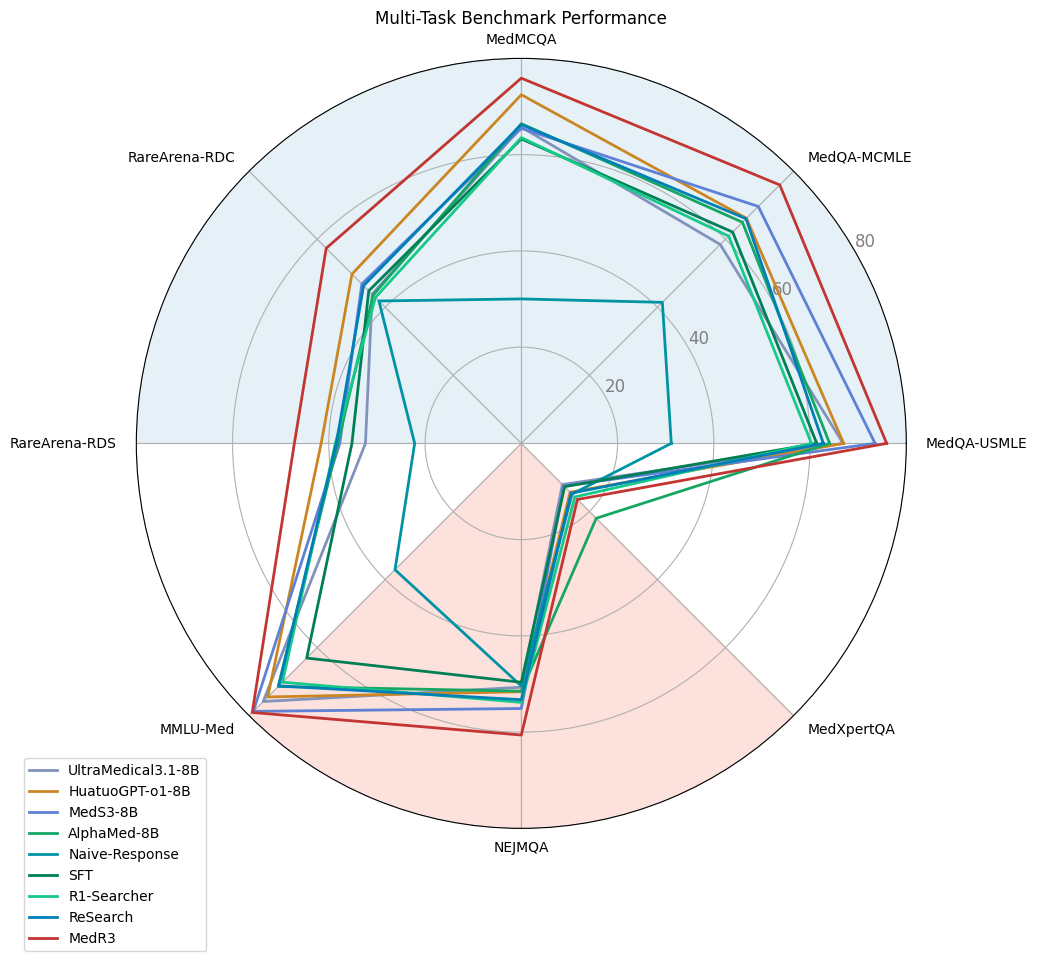

In [ ]:
# sota comparison
import numpy as np
import matplotlib.pyplot as plt
from math import pi
from matplotlib.colors import LinearSegmentedColormap
import json

model_name = "llama3.1-8b-instruct"

categories = ['MedQA-USMLE', 'MedQA-MCMLE', 'MedMCQA', 'RareArena-RDC', 'RareArena-RDS', 'MMLU-Med', 'NEJMQA', 'MedXpertQA']

values1, values2, values3, values4 = [], [], [], []

with open("domain_score.json", "r") as f:
    domain_score = json.load(f)
    values1 = domain_score[model_name]["UltraMedical3.1-8B"]
    values2 = domain_score[model_name]["HuatuoGPT-o1-8B"]
    values3 = domain_score[model_name]["MedS3-8B"]
    values4 = domain_score[model_name]["AlphaMed-8B"]
    values5 = domain_score[model_name]["Naive-Response"]
    values6 = domain_score[model_name]["SFT"]
    values7 = domain_score[model_name]["R1-Searcher"]
    values8 = domain_score[model_name]["ReSearch"]
    values9 = domain_score[model_name]["MedR3"]

domain_color = {
    'law': '#E59191',
    'medicine': '#FAC5BD', # out-of-domain
    'finance': '#F4DFDA',
    'science': '#CCE4F0', # in-domain
    'code': '#AECFD4',
    'others': '#5A9CB4'
}

# 计算每个类别的角度
N = len(categories)
angles = [n / float(N) * 2 * pi for n in range(N)]
values1 += values1[:1]  # 闭合图形
values2 += values2[:1]
values3 += values3[:1]
values4 += values4[:1]
values5 += values5[:1]
values6 += values6[:1]
values7 += values7[:1]
values8 += values8[:1]
values9 += values9[:1]
angles += angles[:1]

# 初始化雷达图
fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))

ax.plot(angles, values1, linewidth=2, linestyle='solid', color='#8192BD', label='UltraMedical3.1-8B')
# ax.fill(angles, values1, 'b', alpha=0.1)
ax.plot(angles, values2, linewidth=2, linestyle='solid', color='#CA8622', label='HuatuoGPT-o1-8B')
# ax.fill(angles, values2, 'r', alpha=0.1)
ax.plot(angles, values3, linewidth=2, linestyle='solid', color='#5E80D5', label='MedS3-8B')
# ax.fill(angles, values3, 'g', alpha=0.1)
ax.plot(angles, values4, linewidth=2, linestyle='solid', color='#15A663', label='AlphaMed-8B')
# ax.fill(angles, values4, 'y', alpha=0.1)
ax.plot(angles, values5, linewidth=2, linestyle='solid', color='#0093A4', label='Naive-Response')
ax.plot(angles, values6, linewidth=2, linestyle='solid', color='#007E54', label='SFT')
ax.plot(angles, values7, linewidth=2, linestyle='solid', color='#17C988', label='R1-Searcher')
ax.plot(angles, values8, linewidth=2, linestyle='solid', color='#007FB7', label='ReSearch')
ax.plot(angles, values9, linewidth=2, linestyle='solid', color='#C23531', label='MedR3')

# 设置雷达图的每个轴的名称及起始位置
plt.xticks(angles[:-1], categories)

# 设置雷达图的范围
ax.set_rlabel_position(30)
plt.yticks([20, 40, 60, 80, 100], ["20", "40", "60", "80", "100"], color="grey", size=12)
plt.ylim(0, 80) # 85

# 调整每个类别的字体位置
for label, angle in zip(ax.get_xticklabels(), angles):
    if angle in (pi / 2, 3 * pi / 2):
        label.set_horizontalalignment('center')
    elif 0 <= angle < pi / 2 or 3 * pi / 2 < angle <= 2 * pi:
        label.set_horizontalalignment('left')
    else:
        label.set_horizontalalignment('right')

# 设置背景颜色
def add_background(ax, start_angle, end_angle, color, alpha=0.5):
    rect = plt.Rectangle((start_angle, 0), end_angle - start_angle, 100, color=color, alpha=alpha, zorder=0)
    ax.add_patch(rect)

""" 设定背景颜色 """
# in-domain 背景颜色
# add_background(ax, angles[0], angles[1], domain_color["science"], alpha=0.5)
add_background(ax, angles[0], angles[1], domain_color["science"], alpha=0.5)
add_background(ax, angles[1], angles[2], domain_color["science"], alpha=0.5)
add_background(ax, angles[2], angles[3], domain_color["science"], alpha=0.5)
add_background(ax, angles[3], angles[4], domain_color["science"], alpha=0.5)
# add_background(ax, angles[4], angles[5], domain_color["science"], alpha=0.5)
# SciEval 和 MMLU-Sci 的背景颜色
add_background(ax, angles[5], angles[6], domain_color["medicine"], alpha=0.5)
add_background(ax, angles[6], angles[7], domain_color["medicine"], alpha=0.5)
# add_background(ax, angles[7], angles[8], domain_color["medicine"], alpha=0.5)
# HumanEval 和 MBPP 的背景颜色
# add_background(ax, angles[8], angles[9], domain_color["code"], alpha=0.5)
# AGIEval 和 HellaSwag 的背景颜色
# add_background(ax, angles[10], angles[11], domain_color["others"], alpha=0.5)

plt.legend(loc='upper right', bbox_to_anchor=(0.1, 0.1))

# 添加标题
plt.title('Multi-Task Benchmark Performance')

# 保存图表为 SVG 文件
plt.savefig(f'{model_name}_radar_chart_medr3.svg', format='svg')

# 显示图表
plt.show()